# Multiple Linear Regression

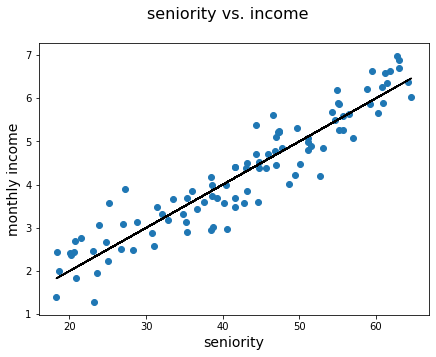

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(1234)
sen = np.random.uniform(18, 65, 100)
income = np.random.normal((sen/10), 0.5)
sen = sen.reshape(-1, 1)

fig = plt.figure(figsize=(7, 5))
fig.suptitle('seniority vs. income', fontsize=16)
plt.scatter(sen, income)
plt.plot(sen, sen/10, c='black')
plt.xlabel('seniority', fontsize=14)
plt.ylabel('monthly income', fontsize=14)
plt.show()

Here, seniority is the independent variable, and monthly income is the target variable.

Of course, you know that seniority is not the only factor that drives income. Other factors that can play a role are, among others, the number of hours worked, years of education, and the city of employment. Now, you could create simple linear regression models for each of these factors and monthly outcome as a target, but more interestingly, you can also create a model where all these potential predictors serve as independent variables at once. How does this work? Let's start with an example with two predictors. As a general expression for our linear model, we had that $\hat Y = bX + a$. Applied to this example, this would boil down to:

$\text{estimated monthly income} = slope * seniority + intercept $


adding in years of education as a predictor, you can extend this model to:

$\text{estimated monthly income} = slope\_sen * seniority + slope\_ed * years\_of\_education  + intercept $

What exactly does that look like?

<img src="assets/01_multiple_linear_regression/multiple_reg.png" width="500">

As we have two predictors here, the simple line is replaced by a **plane**. Our $slope\_sen$ represents the slope in the direction of the axis associated with seniority, our $slope\_ed$ represents the slope in the direction of the axis associated with years of education. 

And it obviously doesn't stop here! We can add as many predictors as we like. What is important to note, however, is that for models with more than two predictors visualizing a multiple linear model becomes very difficult and even impossible! Still, they are used all the time, as linear models of all sorts are extensively helpful in many fields!

When thinking of lines and slopes statistically, slope parameters associated with a particular predictor $x_i$ are often denoted by $\beta_i$. Extending this example mathematically, you would write a multiple linear regression model as follows:

$$ \hat y = \hat\beta_0 + \hat\beta_1 x_1 + \hat\beta_2 x_2 +\ldots + \hat\beta_n x_n $$ 

where $n$ is the number of predictors, $\beta_0$ is the intercept, and $\hat y$ is the so-called "fitted line" or the predicted value associated with the dependent variable.

---

## Multiple Linear Regression in Statsmodels

In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('data/multiple_linear_regression_in_statsmodels/auto-mpg.csv') 
data['horsepower'].astype(str).astype(int)

acc = data['acceleration']
logdisp = np.log(data['displacement'])
loghorse = np.log(data['horsepower'])
logweight= np.log(data['weight'])

scaled_acc = (acc-min(acc))/(max(acc)-min(acc))	
scaled_disp = (logdisp-np.mean(logdisp))/np.sqrt(np.var(logdisp))
scaled_horse = (loghorse-np.mean(loghorse))/(max(loghorse)-min(loghorse))
scaled_weight= (logweight-np.mean(logweight))/np.sqrt(np.var(logweight))

data_fin = pd.DataFrame([])
data_fin['acc'] = scaled_acc
data_fin['disp'] = scaled_disp
data_fin['horse'] = scaled_horse
data_fin['weight'] = scaled_weight
cyl_dummies = pd.get_dummies(data['cylinders'], prefix='cyl', drop_first=True)
yr_dummies = pd.get_dummies(data['model year'], prefix='yr', drop_first=True)
orig_dummies = pd.get_dummies(data['origin'], prefix='orig', drop_first=True)
mpg = data['mpg']
data_fin = pd.concat([mpg, data_fin, cyl_dummies, yr_dummies, orig_dummies], axis=1)

In [ ]:
data_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 23 columns):
mpg       392 non-null float64
acc       392 non-null float64
disp      392 non-null float64
horse     392 non-null float64
weight    392 non-null float64
cyl_4     392 non-null uint8
cyl_5     392 non-null uint8
cyl_6     392 non-null uint8
cyl_8     392 non-null uint8
yr_71     392 non-null uint8
yr_72     392 non-null uint8
yr_73     392 non-null uint8
yr_74     392 non-null uint8
yr_75     392 non-null uint8
yr_76     392 non-null uint8
yr_77     392 non-null uint8
yr_78     392 non-null uint8
yr_79     392 non-null uint8
yr_80     392 non-null uint8
yr_81     392 non-null uint8
yr_82     392 non-null uint8
orig_2    392 non-null uint8
orig_3    392 non-null uint8
dtypes: float64(5), uint8(18)
memory usage: 22.3 KB


For now, let's simplify the model and only inlude `'acc'`, `'horse'` and the three `'orig'` categories in our final data.

In [ ]:
data_ols = pd.concat([mpg, scaled_acc, scaled_weight, orig_dummies], axis=1)
data_ols.head()

,mpg,acceleration,weight,orig_2,orig_3
0,18.0,0.238095,0.720986,0,0
1,15.0,0.208333,0.908047,0,0
2,18.0,0.178571,0.651205,0,0
3,16.0,0.238095,0.648095,0,0
4,17.0,0.148810,0.664652,0,0


## A linear model using statsmodels

Now, let's use the `statsmodels.api` to run OLS on all of the data. Just like for linear regression with a single predictor, you can use the formula $y \sim X$ with $n$ predictors where $X$ is represented as $x_1+\ldots+x_n$.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
formula = 'mpg ~ acceleration+weight+orig_2+orig_3'
model = ols(formula=formula, data=data_ols).fit()

Having to type out all the predictors isn't practical when you have many. Another better way than to type them all out is to seperate out the outcome variable `'mpg'` out of your DataFrame, and use the a `'+'.join()` command on the predictors, as done below:

In [ ]:
outcome = 'mpg'
predictors = data_ols.drop('mpg', axis=1)
pred_sum = '+'.join(predictors.columns)
formula = outcome + '~' + pred_sum

In [ ]:
model = ols(formula=formula, data=data_ols).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     256.7
Date:                Thu, 26 Sep 2019   Prob (F-statistic):          1.86e-107
Time:                        12:01:03   Log-Likelihood:                -1107.2
No. Observations:                 392   AIC:                             2224.
Df Residuals:                     387   BIC:                             2244.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       20.7608      0.688     30.181      0.000      19.408      22.113
acceleration     5.0494      1.389      3.634      0.000       2.318       7.781
weight          -5.8764      0.282    -20.831      0.000      -6.431      -5.322
orig_2           0.4124      0.639      0.645      0.519      -0.844       1.669
orig_3           1.7218      0.653      2.638      0.009       0.438       3.005
==============================================================================
Omnibus:                       37.427   Durbin-Watson:                   0.840
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.989
Skew:                           0.648   Prob(JB):                     6.95e-13
Kurtosis:                       4.322   Cond. No.                         8.47
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Or even easier, simply use the `ols()` function from `statsmodels.api`. The advantage is that you don't have to create the summation string. Important to note, however, is that the intercept term is not included by default, so you have to make sure you manipulate your `predictors` DataFrame so it includes a constant term. You can do this using `.add_constant`.

In [ ]:
import statsmodels.api as sm
predictors_int = sm.add_constant(predictors)
model = sm.OLS(data['mpg'],predictors_int).fit()
model.summary()

//anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     256.7
Date:                Thu, 26 Sep 2019   Prob (F-statistic):          1.86e-107
Time:                        12:01:03   Log-Likelihood:                -1107.2
No. Observations:                 392   AIC:                             2224.
Df Residuals:                     387   BIC:                             2244.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           20.7608      0.688     30.181      0.000      19.408      22.113
acceleration     5.0494      1.389      3.634      0.000       2.318       7.781
weight          -5.8764      0.282    -20.831      0.000      -6.431      -5.322
orig_2           0.4124      0.639      0.645      0.519      -0.844       1.669
orig_3           1.7218      0.653      2.638      0.009       0.438       3.005
==============================================================================
Omnibus:                       37.427   Durbin-Watson:                   0.840
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.989
Skew:                           0.648   Prob(JB):                     6.95e-13
Kurtosis:                       4.322   Cond. No.                         8.47
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretation

Just like for single multiple regression, the coefficients for the model should be interpreted as "how does $y$ change for each additional unit $X$"? However, do note that since $X$ was transformed, the interpretation can sometimes require a little more attention. In fact, as the model is built on the transformed $X$, the actual relationship is "how does $y$ change for each additional unit $X'$", where $X'$ is the (log- and min-max, standardized,...) transformed data matrix.

## Linear regression using scikit-learn

You can also repeat this process using scikit-learn. The code to do this can be found below. The scikit-learn package is known for its machine learning functionalities and generally very popular when it comes to building a clear data science workflow. It is also commonly used by data scientists for regression. The disadvantage of scikit-learn compared to statsmodels is that it doesn't have some statistical metrics like the p-values of the parameter estimates readily available. For a more *ad-hoc* comparison of scikit-learn and statsmodels, you can read this blogpost: https://blog.thedataincubator.com/2017/11/scikit-learn-vs-statsmodels/.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
y = data_ols['mpg']
linreg = LinearRegression()
linreg.fit(predictors, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
# coefficients
linreg.coef_

array([ 5.04941007, -5.87640551,  0.41237454,  1.72184708])

The intercept of the model is stored in the `.intercept_` attribute.

In [ ]:
# intercept
linreg.intercept_

20.760757080821836

---

## Practice

## Introduction
In this lab, you'll practice fitting a multiple linear regression model on the Boston Housing dataset!

## Objectives
You will be able to:
* Determine if it is necessary to perform normalization/standardization for a specific model or set of data
* Use standardization/normalization on features of a dataset
* Identify if it is necessary to perform log transformations on a set of features
* Perform log transformations on different features of a dataset
* Use statsmodels to fit a multiple linear regression model
* Evaluate a linear regression model by using statistical performance metrics pertaining to overall model and specific parameters

## The Boston Housing Data

We pre-processed the Boston Housing data again. This time, however, we did things slightly different:
- We dropped `'ZN'` and `'NOX'` completely 
- We categorized `'RAD'` in 3 bins and `'TAX'` in 4 bins
- We transformed `'RAD'` and `'TAX'` to dummy variables and dropped the first variable to eliminate multicollinearity
- We used min-max-scaling on `'B'`, `'CRIM'`, and `'DIS'` (and log transformed all of them first, except `'B'`)
- We used standardization on `'AGE'`, `'INDUS'`, `'LSTAT'`, and `'PTRATIO'` (and log transformed all of them first, except for `'AGE'`)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_boston
boston = load_boston()

boston_features = pd.DataFrame(boston.data, columns = boston.feature_names)
boston_features = boston_features.drop(['NOX', 'ZN'],axis=1)

# First, create bins for based on the values observed. 3 values will result in 2 bins
bins = [0, 6, 24]
bins_rad = pd.cut(boston_features['RAD'], bins)
bins_rad = bins_rad.cat.as_unordered()

# First, create bins for based on the values observed. 4 values will result in 3 bins
bins = [0, 270, 360, 712]
bins_tax = pd.cut(boston_features['TAX'], bins)
bins_tax = bins_tax.cat.as_unordered()

tax_dummy = pd.get_dummies(bins_tax, prefix='TAX', drop_first=True)
rad_dummy = pd.get_dummies(bins_rad, prefix='RAD', drop_first=True)
boston_features = boston_features.drop(['RAD','TAX'], axis=1)
boston_features = pd.concat([boston_features, rad_dummy, tax_dummy], axis=1)

In [ ]:
age = boston_features['AGE']
b = boston_features['B']
logcrim = np.log(boston_features['CRIM'])
logdis = np.log(boston_features['DIS'])
logindus = np.log(boston_features['INDUS'])
loglstat = np.log(boston_features['LSTAT'])
logptratio = np.log(boston_features['PTRATIO'])

# Min-Max scaling
boston_features['B'] = (b-min(b))/(max(b)-min(b))
boston_features['CRIM'] = (logcrim-min(logcrim))/(max(logcrim)-min(logcrim))
boston_features['DIS'] = (logdis-min(logdis))/(max(logdis)-min(logdis))

# Standardization
boston_features['AGE'] = (age-np.mean(age))/np.sqrt(np.var(age))
boston_features['INDUS'] = (logindus-np.mean(logindus))/np.sqrt(np.var(logindus))
boston_features['LSTAT'] = (loglstat-np.mean(loglstat))/np.sqrt(np.var(loglstat))
boston_features['PTRATIO'] = (logptratio-np.mean(logptratio))/(np.sqrt(np.var(logptratio)))

In [ ]:
boston_features.head()

## Run a linear model in statsmodels

In [ ]:
# Your code here

## Run the same model in scikit-learn

In [ ]:
# Your code here - Check that the coefficients and intercept are the same as those from Statsmodels

## Interpret the coefficients for PTRATIO, PTRATIO, LSTAT

- CRIM: per capita crime rate by town
- INDUS: proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- RM: average number of rooms per dwelling
- AGE: proportion of owner-occupied units built prior to 1940
- DIS: weighted distances to five Boston employment centres
- RAD: index of accessibility to radial highways
- TAX: full-value property-tax rate per $10,000
- PTRATIO: pupil-teacher ratio by town
- B: 1000(Bk - 0.63)^2 where Bk is the proportion of African American individuals by town
- LSTAT: % lower status of the population

## Predict the house price given the following characteristics (before manipulation!!)

Make sure to transform your variables as needed!

- CRIM: 0.15
- INDUS: 6.07
- CHAS: 1        
- RM:  6.1
- AGE: 33.2
- DIS: 7.6
- PTRATIO: 17
- B: 383
- LSTAT: 10.87
- RAD: 8
- TAX: 284